In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


**Importing Required Libraries for Data Processing and Modeling**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split,RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



**Understanding data structures**

In [3]:
train = pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
test_df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/test.csv")

In [4]:

df = train.copy() 

print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nSummary Statistics:")
print(df.describe())

#distribution of the target variable
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm       

**Insights:**
There are missing values in key numerical features which should be handled via imputation or removal.
Some categorical features need encoding before training the model.
The dataset contains high-dimensional categorical features like MachineID and ProductName, which might not be useful for modeling directly and could be dropped.

****Data Preprocessing (Handling Missing Values, Outliers and Encoding Categorical Column)****

In [5]:
# Function to detect and handle outliers using IQR method
def handle_outliers_iqr(df, method="replace", replacement_method="median"):
    df_cleaned = df.copy()
    for col in df_cleaned.select_dtypes(include=[np.number]).columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if method == "remove":
            df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
        elif method == "replace":
            replacement_value = df_cleaned[col].median() if replacement_method == "median" else df_cleaned[col].mean()
            df_cleaned.loc[df_cleaned[col] < lower_bound, col] = replacement_value
            df_cleaned.loc[df_cleaned[col] > upper_bound, col] = replacement_value
    
    return df_cleaned

# Function to label encode categorical features
def label_encode(df):
    label_encoders = {}
    for col in df.select_dtypes(include=["object"]).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    return df, label_encoders

# Preprocessing Pipeline
def preprocess_data(df, method="replace", replacement_method="median"):
    missing_values = df.isnull().mean() * 100
    high_missing_cols = missing_values[missing_values > 50].index
    df = df.drop(columns=high_missing_cols)
    
    # Identify numerical and categorical columns
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # ColumnTransformer for handling missing values and scaling
    preprocessor = ColumnTransformer([
        ("num_imputer", SimpleImputer(strategy="median"), num_cols),
        ("cat_imputer", SimpleImputer(strategy="most_frequent"), cat_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)
    
    df_transformed = preprocessor.fit_transform(df)
    df_transformed = pd.DataFrame(df_transformed, columns=num_cols + cat_cols, index=df.index)
    
    df_transformed = handle_outliers_iqr(df_transformed, method, replacement_method)
    
    # Label encode categorical features
    df_encoded, label_encoders = label_encode(df_transformed)
    
    return df_encoded, num_cols, cat_cols, label_encoders

# high_cardinality_cols = ["MachineID", "OSBuildLab"]
#"Census_OSVersion", "Census_OSBranch", "DateOS", "DateAS"
# df_cleaned = df_cleaned.drop(columns=[col for col in high_cardinality_cols if col in df_cleaned.columns], errors='ignore')
# test_df_cleaned = test_df_cleaned.drop(columns=[col for col in high_cardinality_cols if col in test_df_cleaned.columns], errors='ignore')



df_cleaned, num_cols, cat_cols, label_encoders = preprocess_data(df)
test_df_cleaned, _, _, _ = preprocess_data(test_df)

print("Preprocessing completed.")

Preprocessing completed.


**Insights:** The preprocessing pipeline handles outliers using the IQR method,ensuring data 
consistency. Missing Values are addressed by dropping columns with over 50% missing data
and imputing the rest, reducing bias.
Categorical features are label-encoded for model compatibility. 

**Missing values heatmap**

Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


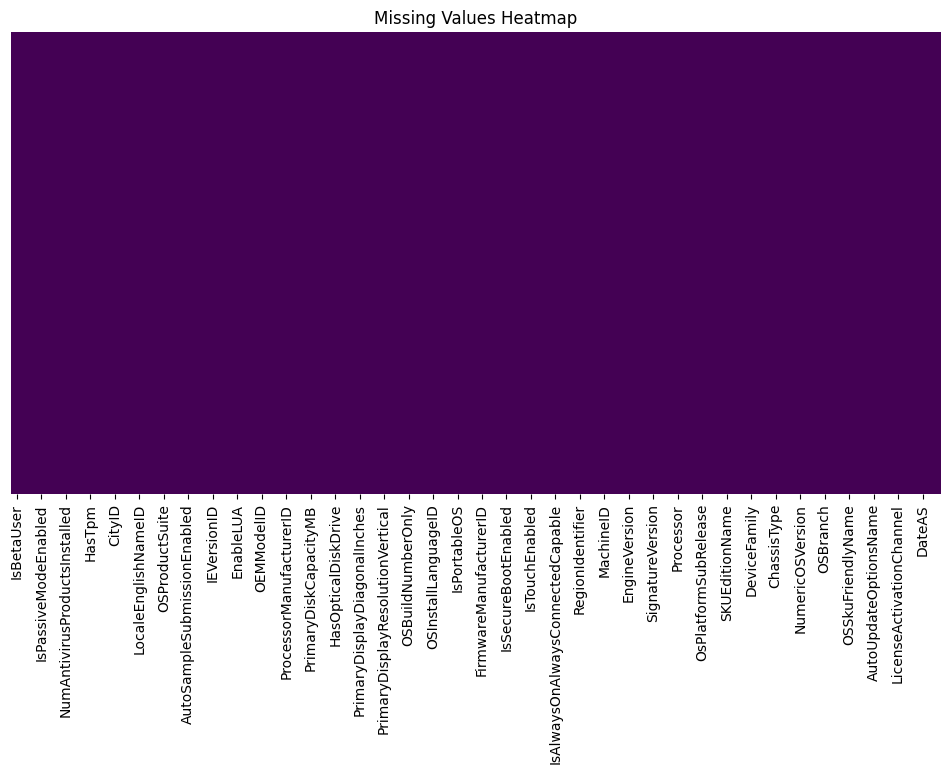

In [6]:
#Verifying  missing values using Plot

missing_values = df_cleaned.isnull().sum()
missing_percent = (df_cleaned.isnull().sum() / len(df)) * 100

#missing values in descending order
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_df)

plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


**Insights:** Missing values heatmap appears to be entirely blank, meaning there are no missing values in dataset after preprocessing. This suggests that imputation or cleaning process successfully handled all missing data.

**Histograms and Boxplots**

Checking for infinite values:
 IsBetaUser                       0
RealTimeProtectionState          0
IsPassiveModeEnabled             0
AntivirusConfigID                0
NumAntivirusProductsInstalled    0
                                ..
OSGenuineState                   0
LicenseActivationChannel         0
FlightRing                       0
DateAS                           0
DateOS                           0
Length: 76, dtype: int64


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

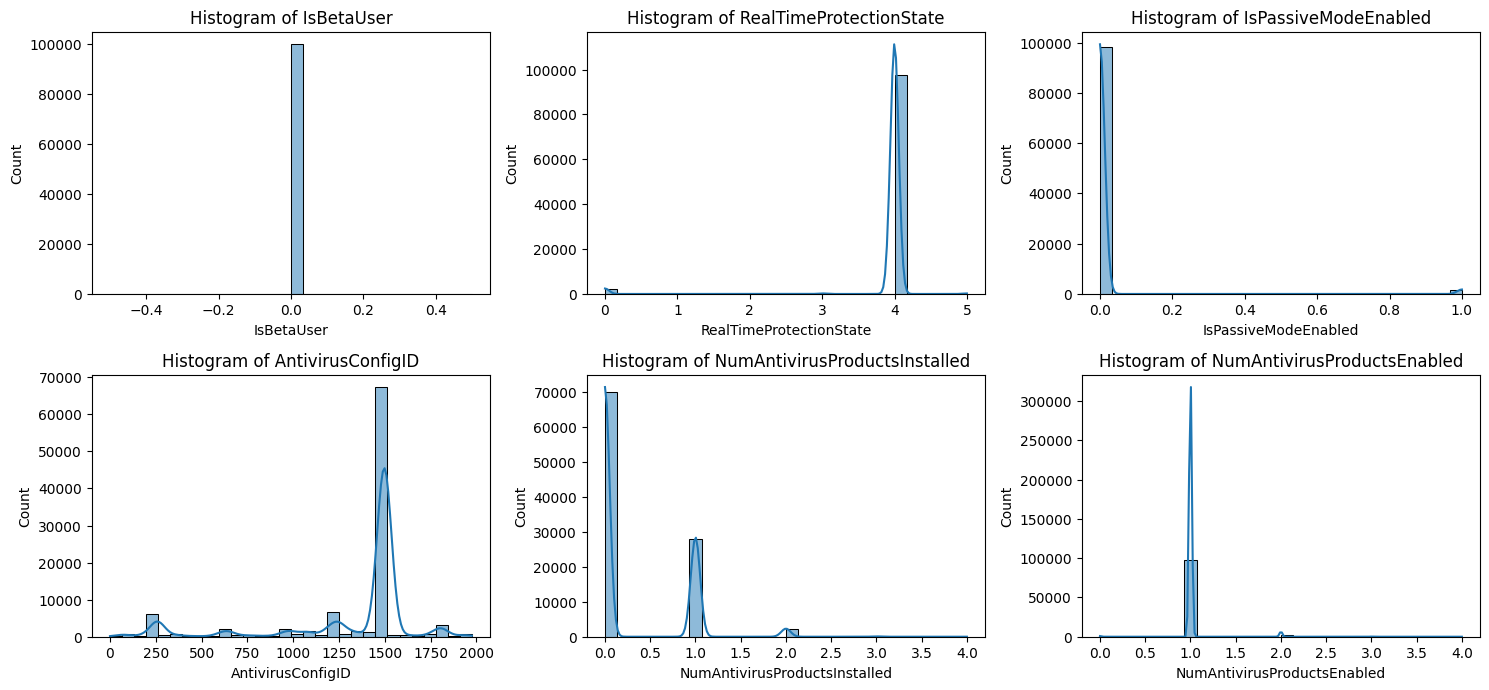

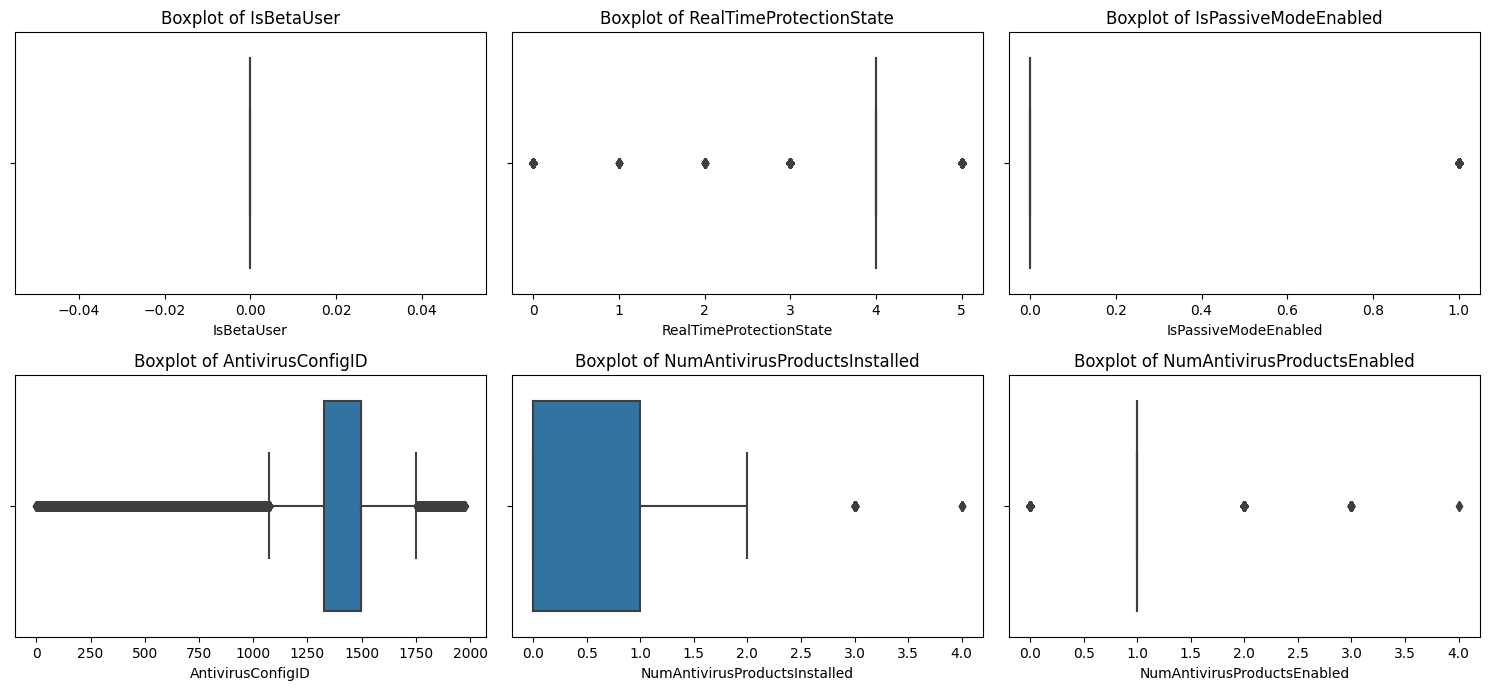

In [7]:

print("Checking for infinite values:\n", df_cleaned.replace([np.inf, -np.inf], np.nan).isnull().sum())
df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan)

df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)

numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols[:6]):  # Adjusting to show first 6 columns for better visibility
    plt.subplot(3, 3, i+1)
    sns.histplot(df_cleaned[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols[:6]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df_cleaned[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


**Insights:** Most features are highly skewed (right-skewed).This indicates that a large portion
of the data is concentrated at lower values, with a few extreme values pulling the distribution rightward.


**Feature correlation analysis**

Constant columns: ['IsBetaUser', 'AutoSampleSubmissionEnabled', 'IsFlightsDisabled']


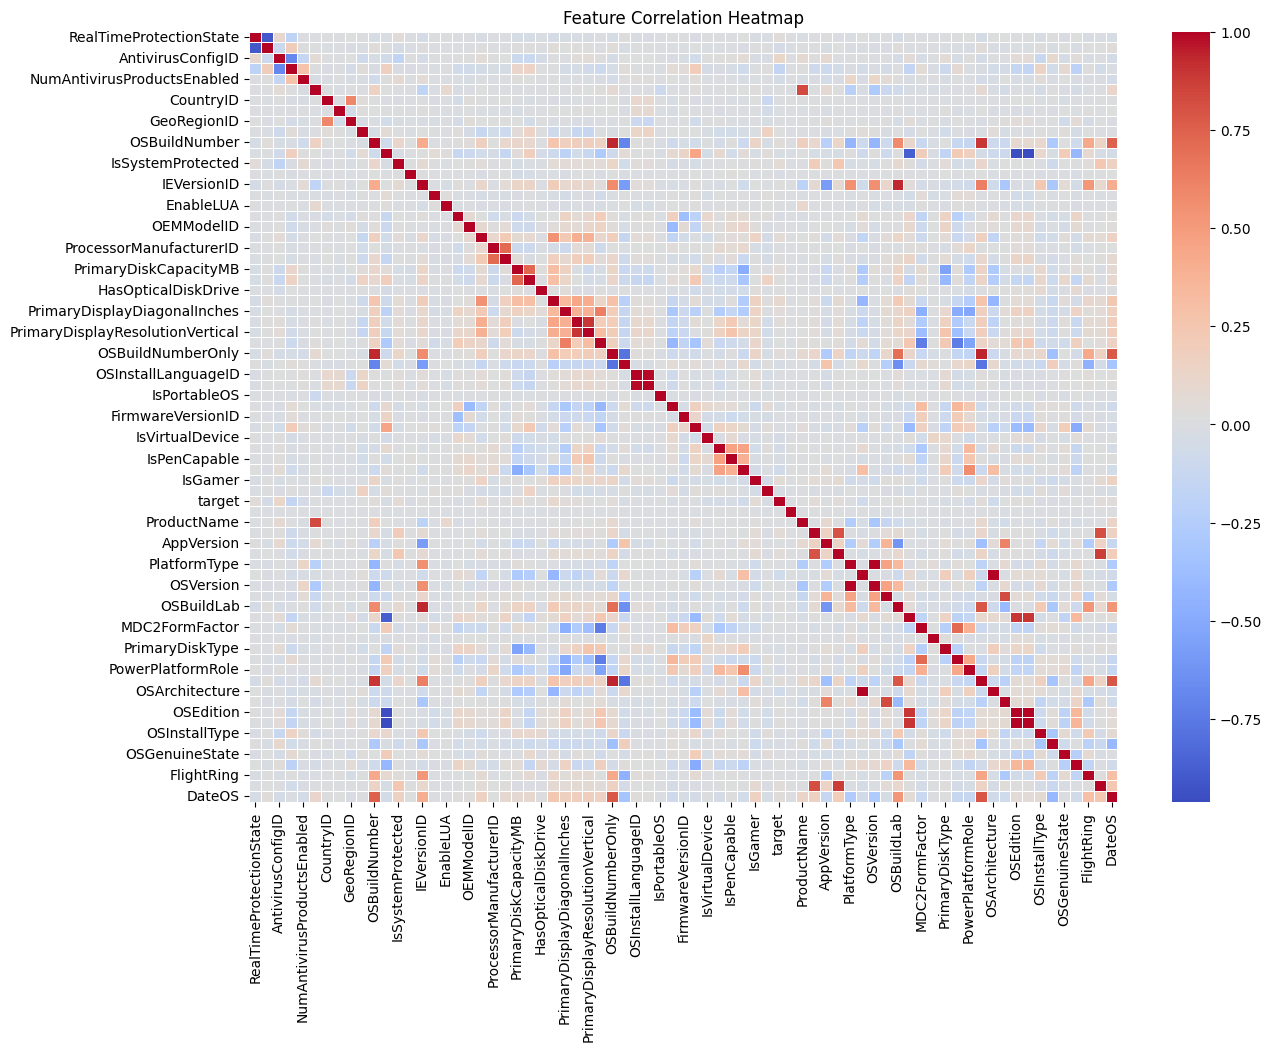

In [8]:
# def remove_constant_and_correlated_features(df_cleaned, correlation_threshold=0.85):
constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() == 1]
print("Constant columns:", constant_cols)

df_cleaned.drop(columns=constant_cols, inplace=True)

corr_matrix = df_cleaned.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

#     # Highly correlated features
#     high_corr_features = set()

#     for i in range(len(corr_matrix.columns)):
#         for j in range(i):
#             if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
#                 colname = corr_matrix.columns[i]
#                 high_corr_features.add(colname)

#     print(f"Highly correlated features (>{correlation_threshold} correlation):", high_corr_features)

#     # Drop highly correlated features
#     df_cleaned.drop(columns=high_corr_features, inplace=True)
    
#     return df_cleaned

# df_cleaned = remove_constant_and_correlated_features(df_cleaned, correlation_threshold=0.85)
# test_df_cleaned = remove_constant_and_correlated_features(test_df_cleaned, correlation_threshold=0.85)


**Insights:** The correlation matrix shows that most features have weak correlations with each other, indicating they contribute unique information. Some OS-related features are highly correlated.

**Checking for class imbalance**

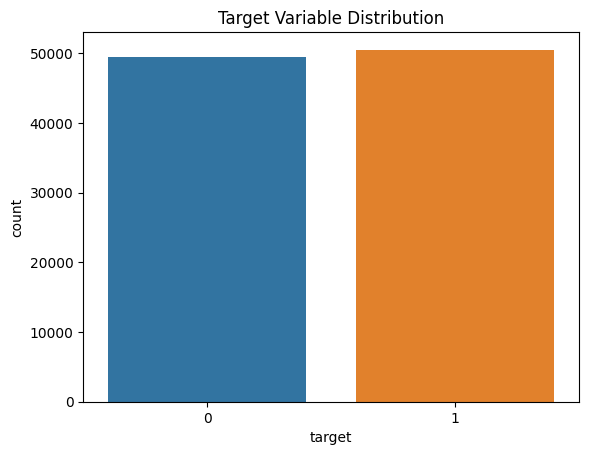

Class Distribution:
 target
1    50.525
0    49.475
Name: proportion, dtype: float64


In [9]:

sns.countplot(x=df['target'])
plt.title("Target Variable Distribution")
plt.show()

class_counts = df['target'].value_counts(normalize=True) * 100
print("Class Distribution:\n", class_counts)


**Insights:** There is slight imbalance in the dataset but that is acceptable.

**Feature Selection**

Selected 70 Features (Using RFE):
['RealTimeProtectionState', 'IsPassiveModeEnabled', 'AntivirusConfigID', 'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled', 'HasTpm', 'CountryID', 'CityID', 'GeoRegionID', 'LocaleEnglishNameID', 'OSBuildNumber', 'OSProductSuite', 'IsSystemProtected', 'SMode', 'IEVersionID', 'FirewallEnabled', 'EnableLUA', 'OEMNameID', 'OEMModelID', 'ProcessorCoreCount', 'ProcessorManufacturerID', 'ProcessorModelID', 'PrimaryDiskCapacityMB', 'SystemVolumeCapacityMB', 'HasOpticalDiskDrive', 'TotalPhysicalRAMMB', 'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal', 'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges', 'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSInstallLanguageID', 'OSUILocaleID', 'FirmwareManufacturerID', 'FirmwareVersionID', 'IsSecureBootEnabled', 'IsVirtualDevice', 'IsTouchEnabled', 'IsPenCapable', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer', 'RegionIdentifier', 'MachineID', 'ProductName', 'EngineVersio

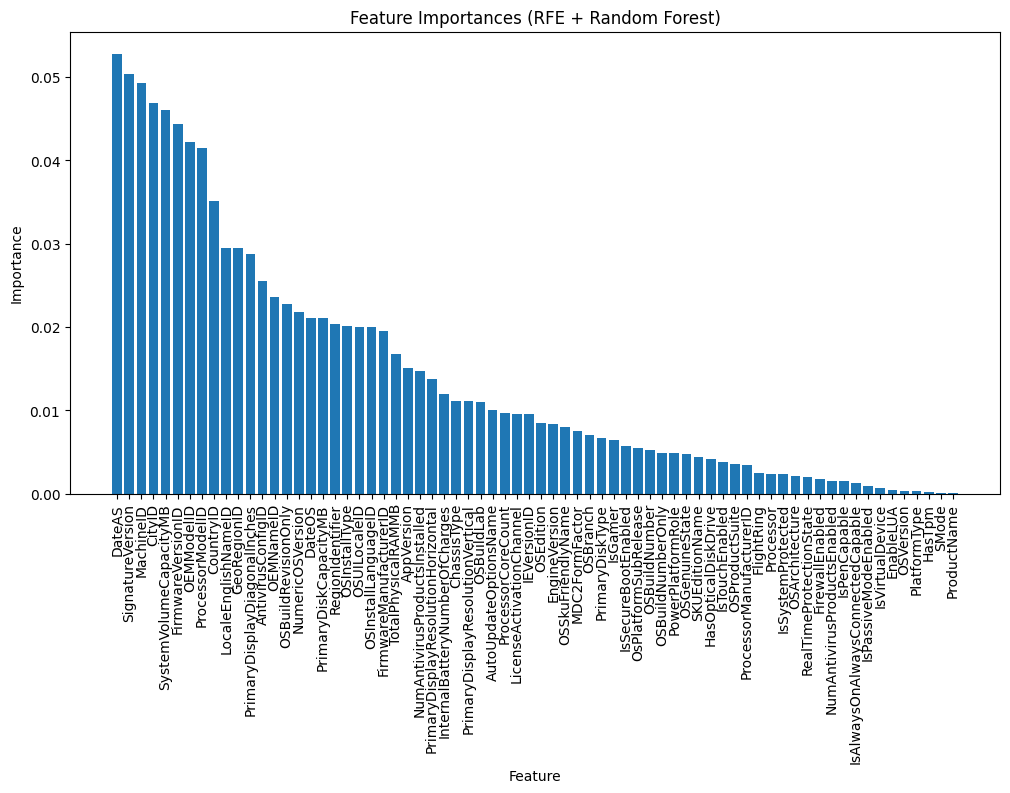

Missing 0 Columns in Test Set: []


In [10]:

def select_top_features(df, target_column, n_features=60):
    """
    Selects the top `n_features` using Recursive Feature Elimination (RFE)
    with a RandomForestClassifier as the estimator.
    """
    X = df.drop(columns=[target_column])  
    y = df[target_column]
    
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    
    # Use RFE to select top features
    rfe = RFE(estimator=rf, n_features_to_select=n_features)
    rfe.fit(X, y)
    
    selected_features = X.columns[rfe.support_]
    
    print(f"Selected {len(selected_features)} Features (Using RFE):")
    print(list(selected_features))
    
    feature_importances = rf.fit(X[selected_features], y).feature_importances_
    sorted_indices = np.argsort(feature_importances)[::-1]  # Sort descending

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(feature_importances)), feature_importances[sorted_indices])
    plt.xticks(range(len(feature_importances)), np.array(selected_features)[sorted_indices], 
               rotation=90)
    plt.title("Feature Importances (RFE + Random Forest)")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.show()
    
    return df[selected_features], y, selected_features, rf

df_cleaned, y, selected_features, rf_model = select_top_features(df_cleaned, "target",
                                                                  n_features=70)

# Ensuring selected features exist in the test set
missing_cols = [col for col in selected_features if col not in test_df_cleaned.columns]
print(f"Missing {len(missing_cols)} Columns in Test Set: {missing_cols}")

# Add missing columns with default value 0
for col in missing_cols:
    test_df_cleaned[col] = 0  

# Select the same features in the test set
test_df_cleaned = test_df_cleaned[selected_features]

**Insights:** Features like DateAS, Signature Version, SystemVolumeCapacity, and Firmware have the highest importance in predicting the target variable.Many features have near-zero importance, meaning they add little to model performance.

**Feature scaling**

In [11]:
scaler = StandardScaler()

#List of numerical features (excluding categorical and target variable)
num_features = [col for col in df_cleaned.columns if col not in ['target']] 
test_num_features = [col for col in test_df_cleaned.columns]

# Scale train data
df_cleaned[num_features] = scaler.fit_transform(df_cleaned[num_features])

# Use the same scaler to transform test data
test_df_cleaned[test_num_features] = scaler.transform(test_df_cleaned[test_num_features])


In [12]:

# Set a threshold (0.01 to remove features with very low variance)
# threshold = 0.001
# selector = VarianceThreshold(threshold=threshold)
# X_selected = selector.fit_transform(df_cleaned)

# selected_features = df_cleaned.columns[selector.get_support()]

# new dataframe with only the selected features
# df_selected = pd.DataFrame(X_selected, columns=selected_features)

# # Add the target column back
# # df_selected['target'] = y

# print(f"Reduced from {df_cleaned.shape[1]} to {df_selected.shape[1] - 1} features.")

# # Apply the same feature selection to test dataset
# selected_features_test = [col for col in selected_features if col in test_df_cleaned.columns]

# X_test_selected = test_df_cleaned[selected_features_test]  # Keep only the selected features

# # Convert to DataFrame for consistency
# test_df_selected = pd.DataFrame(X_test_selected, columns=selected_features)

# print(f"Test dataset reduced to {test_df_selected.shape[1]} features.")

# # Save the new dataframe if needed
# # df_selected.to_csv("filtered_dataset.csv", index=False)


**PCA for reducing dimensionality**

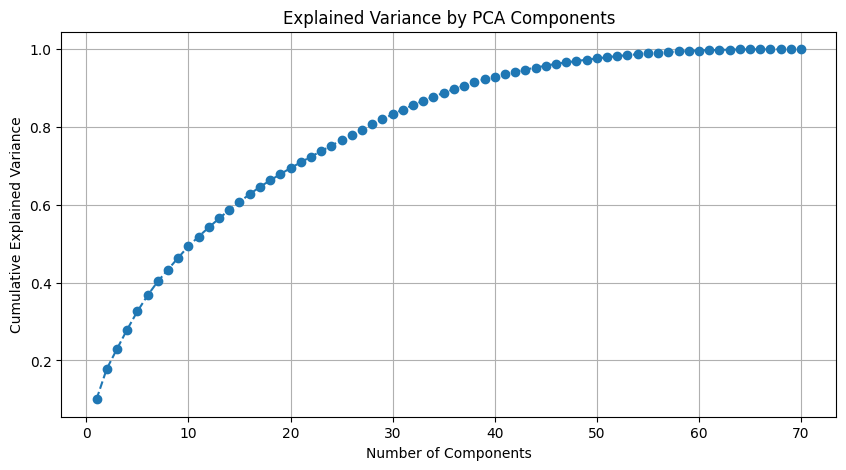

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  0.146948 -0.133925  0.424489 -0.626788 -0.117566  0.056837 -0.906825   
1  0.146948 -0.133925  0.424489 -0.626788 -0.117566  0.056837  0.532993   
2  0.146948 -0.133925  0.424489 -0.626788 -0.117566  0.056837 -0.906825   
3  0.146948 -0.133925 -0.350536  1.294225 -0.117566  0.056837 -0.634860   
4  0.146948 -0.133925 -0.982322  1.294225 -0.117566  0.056837 -1.034809   

        PC8       PC9      PC10  ...      PC61      PC62      PC63      PC64  \
0  0.817510 -0.824960 -0.142393  ... -1.522103 -0.973449 -0.957807  0.795470   
1  0.653631 -0.005569  1.444027  ...  0.380259  1.277956  1.294050  0.317193   
2 -0.796446 -0.824960 -0.142393  ...  0.380259 -0.973449 -0.957807 -0.161084   
3 -1.249433  1.174908 -0.699783  ... -1.141630 -0.973449 -0.957807  1.273747   
4  0.766770 -1.311039 -1.300050  ...  0.380259  1.277956  1.294050  0.317193   

       PC65      PC66      PC67      PC68      PC69      PC70  
0  1

In [13]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned)
X_test_scaled_features = scaler.fit_transform(test_df_cleaned)


pca = PCA(n_components=None)  
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
    pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

# explained_variance = pca.explained_variance_ratio_.cumsum()
# n_components = next(i for i, v in enumerate(explained_variance) if v >= 0.97) + 1
# print(f"Optimal number of components: {n_components}")

# pca = PCA(n_components=n_components)
# X_reduced = pca.fit_transform(X_scaled)
# X_test_reduced = pca.fit_transform(X_test_scaled_features)

pca_df = pd.DataFrame(data=X_scaled, columns=[f"PC{i+1}" for i in range(70)])
test_pca_df = pd.DataFrame(data=X_test_scaled_features, columns=[f"PC{i+1}" for i in range(70)])

# print(f"Original shape: {df_cleaned.shape}, Reduced shape: {X_reduced.shape}")
# print(X_test_reduced.shape)

print(pca_df.head())
print(test_pca_df.head())


**Insights:** PCA plot is a Cumulative Explained Variance Plot, which helps determine the optimal number of principal components (PCs) to retain.
X-axis (Number of Components): Represents the principal components.
Y-axis (Cumulative Explained Variance): The proportion of the total variance retained when using a certain number of components.
Blue Dots show how variance increases as we include more PCs.
The first few components capture most of the variance.
Beyond a certain point, adding more PCs doesn't increase variance much.
This "elbow" is where consider stopping.

**Dummy Classifier**

In [14]:


X_train, X_val, y_train, y_val = train_test_split(pca_df, y, test_size=0.2, random_state=42)

#train a Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_val)

baseline_accuracy = accuracy_score(y_val, y_pred_dummy)
print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")

y_test_pred_bl =dummy_clf.predict(test_pca_df)

y_test_pred_bl = pd.DataFrame(y_test_pred_bl)
y_test_pred_bl.value_counts()


Baseline Model Accuracy: 0.4975


0
0    5000
1    5000
Name: count, dtype: int64

**Pipeline**

In [15]:

#X_train, X_val, y_train, y_val = train_test_split(pca_df, y, test_size=0.2, random_state=42)

param_grid = {
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 1, 10],
        "model__max_iter": [500, 1000],
        "svd__n_components": [20, 30]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [None, 10, 20],
        "svd__n_components": [20, 30]
    },
    "Bagging Classifier": {
        "model__n_estimators": [5, 10, 20],
        "svd__n_components": [20, 30]
    }
}

models = {
    "Logistic Regression": Pipeline([
        ("svd", TruncatedSVD(n_components=30, random_state=42)),
        ("model", LogisticRegression(random_state=42, class_weight='balanced'))
    ]),
    "Random Forest": Pipeline([
        ("svd", TruncatedSVD(n_components=30, random_state=42)),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "Bagging Classifier": Pipeline([
        ("svd", TruncatedSVD(n_components=30, random_state=42)),
        ("model", BaggingClassifier(base_estimator=LogisticRegression(random_state=42), random_state=42))
    ])
}

# Train and evaluate models with hyperparameter tuning
best_model = None
best_score = 0
for name, pipeline in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(pipeline, param_grid[name], scoring='roc_auc', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_pipeline = grid_search.best_estimator_
    best_params = grid_search.best_params_
    y_pred = best_pipeline.predict(X_val)
    roc_auc = roc_auc_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    
    print(f"{name} Best Params: {best_params}")
    print(f"{name} ROC-AUC: {roc_auc:.4f}")
    print(f"{name} Accuracy: {accuracy:.4f}\n")
    
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = best_pipeline

# Predict on test set using best model
test_predictions = best_model.predict(test_pca_df)


Tuning Logistic Regression...
Logistic Regression Best Params: {'model__C': 10, 'model__max_iter': 500, 'svd__n_components': 30}
Logistic Regression ROC-AUC: 0.5898
Logistic Regression Accuracy: 0.5906

Tuning Random Forest...
Random Forest Best Params: {'model__max_depth': 20, 'model__n_estimators': 200, 'svd__n_components': 30}
Random Forest ROC-AUC: 0.6035
Random Forest Accuracy: 0.6045

Tuning Bagging Classifier...


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Bagging Classifier Best Params: {'model__n_estimators': 20, 'svd__n_components': 30}
Bagging Classifier ROC-AUC: 0.5892
Bagging Classifier Accuracy: 0.5901



**Insights:** Tree-based models (like Random Forest) perform slightly better, indicating non-linearity in the data.

[1]	valid_0's auc: 0.639813
Training until validation scores don't improve for 50 rounds
[2]	valid_0's auc: 0.648367
[3]	valid_0's auc: 0.649447
[4]	valid_0's auc: 0.650582
[5]	valid_0's auc: 0.650876
[6]	valid_0's auc: 0.651989
[7]	valid_0's auc: 0.652053
[8]	valid_0's auc: 0.653299
[9]	valid_0's auc: 0.653518
[10]	valid_0's auc: 0.655423
[11]	valid_0's auc: 0.656063
[12]	valid_0's auc: 0.656583
[13]	valid_0's auc: 0.656856
[14]	valid_0's auc: 0.656885
[15]	valid_0's auc: 0.657278
[16]	valid_0's auc: 0.657461
[17]	valid_0's auc: 0.658235
[18]	valid_0's auc: 0.658127
[19]	valid_0's auc: 0.658855
[20]	valid_0's auc: 0.65897
[21]	valid_0's auc: 0.659969
[22]	valid_0's auc: 0.660897
[23]	valid_0's auc: 0.660929
[24]	valid_0's auc: 0.661597
[25]	valid_0's auc: 0.661859
[26]	valid_0's auc: 0.662335
[27]	valid_0's auc: 0.662565
[28]	valid_0's auc: 0.662873
[29]	valid_0's auc: 0.663147
[30]	valid_0's auc: 0.66359
[31]	valid_0's auc: 0.664071
[32]	valid_0's auc: 0.664448
[33]	valid_0's auc: 0.

<Figure size 600x500 with 0 Axes>

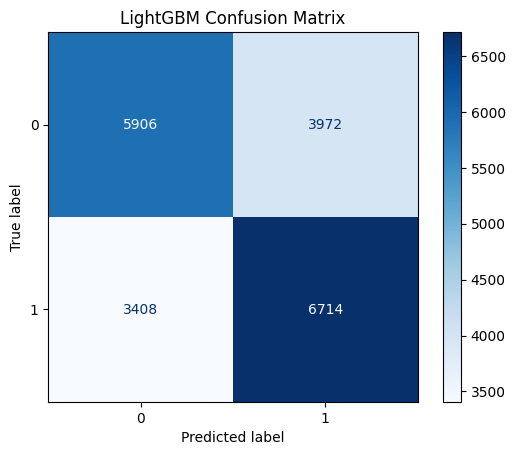

In [16]:

#Initialize and train LightGBM classifier
lgbm_model = LGBMClassifier(
    objective="binary",
    metric="accuracy",
    boosting_type="gbdt",
    num_leaves=31,  
    learning_rate=0.05,  
    n_estimators=200,  
    max_depth=-1,  
    random_state=42,  
    class_weight="balanced",
    lambda_l1=0.1,  
    lambda_l2=1.0,  
    min_data_in_leaf=20,   
    feature_fraction=0.8,  
    bagging_fraction=0.8,  
    bagging_freq=5,  
    verbose=-1
)

early_stopping_callback = early_stopping(stopping_rounds=50)
log_evaluation_callback = log_evaluation(period=1)

lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
               eval_metric="auc",
               callbacks=[early_stopping_callback, log_evaluation_callback])

y_pred = lgbm_model.predict(X_val)
y_prob = lgbm_model.predict_proba(X_val)[:, 1]  # Get probability for positive class

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

print("\nLightGBM Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

y_test_pred_lgbm = lgbm_model.predict(test_pca_df)

y_test_pred_lgbm_df = pd.DataFrame(y_test_pred_lgbm)
y_test_pred_lgbm_df.value_counts

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("LightGBM Confusion Matrix")
plt.show()

**Insights:** Introduced a strong model (LightGBM), which usually outperforms Random Forest and Logistic Regression due to better handling of complex patterns.
The model uses balanced class weights, meaning it automatically adjusts for class imbalance.
The model is identifying a reasonable number of true threats (TP) and non-threats (TN).


**Submission file**

In [ ]:

submission_df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/sample_submission.csv")

submission_df["target"] = y_test_pred_lgbm

submission_df.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")
